# Analyse Pijuan-sala 2019 SS2 of Allantois, YS, and EP endothelium

In [1]:
library(Seurat)
library(data.table)
library(dplyr)
library(ggplot2)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
meta = fread('pijuansala2019_ss2_metadata.txt')[,c('Factor Value[organism part]', 'Factor Value[single cell identifier]')] %>%
    setnames(c('tissue','cell'))
counts = fread('pijuansala2019_ss2_logcounts.txt')

Warning message in fread("pijuansala2019_ss2_logcounts.txt"):
“Detected 250 column names but the data has 251 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [3]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genes = data.table(id = counts$V1,
                   name = genenames[match(counts$V1, gene), gene_name]) %>%
            .[name!='' & !is.na(name)]
counts.mtx = counts[match(genes$id, V1),][,V1:=NULL] %>% as.matrix
rownames(counts.mtx) = genes$name
#counts.mtx = counts.mtx[!is.na(rownames(counts.mtx)),]

In [4]:
meta.df = meta %>% as.data.frame()
rownames(meta.df) = meta.df$cell

In [5]:
seurat = CreateSeuratObject(counts.mtx, meta.data = meta.df)

Warning message in CreateSeuratObject.default(counts.mtx, meta.data = meta.df):
“Some cells in meta.data not present in provided counts matrix”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”


In [6]:
all.genes <- rownames(seurat)
seurat <- ScaleData(seurat, features = all.genes)

Centering and scaling data matrix



In [7]:
seurat

An object of class Seurat 
50239 features across 250 samples within 1 assay 
Active assay: RNA (50239 features, 0 variable features)

In [8]:
Idents(seurat) = seurat@meta.data$tissue

In [9]:
markers = FindAllMarkers(seurat)

Calculating cluster yolk sac

Calculating cluster embryo

Calculating cluster allantois



In [10]:
top = markers %>% 
    group_by(cluster) %>%
        dplyr::filter(avg_log2FC > 1) %>%
        slice_head(n = 300) %>%
        ungroup()

In [13]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/SS2"

In [14]:
fwrite(top, 'Endothelial_subset_markers.txt')

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


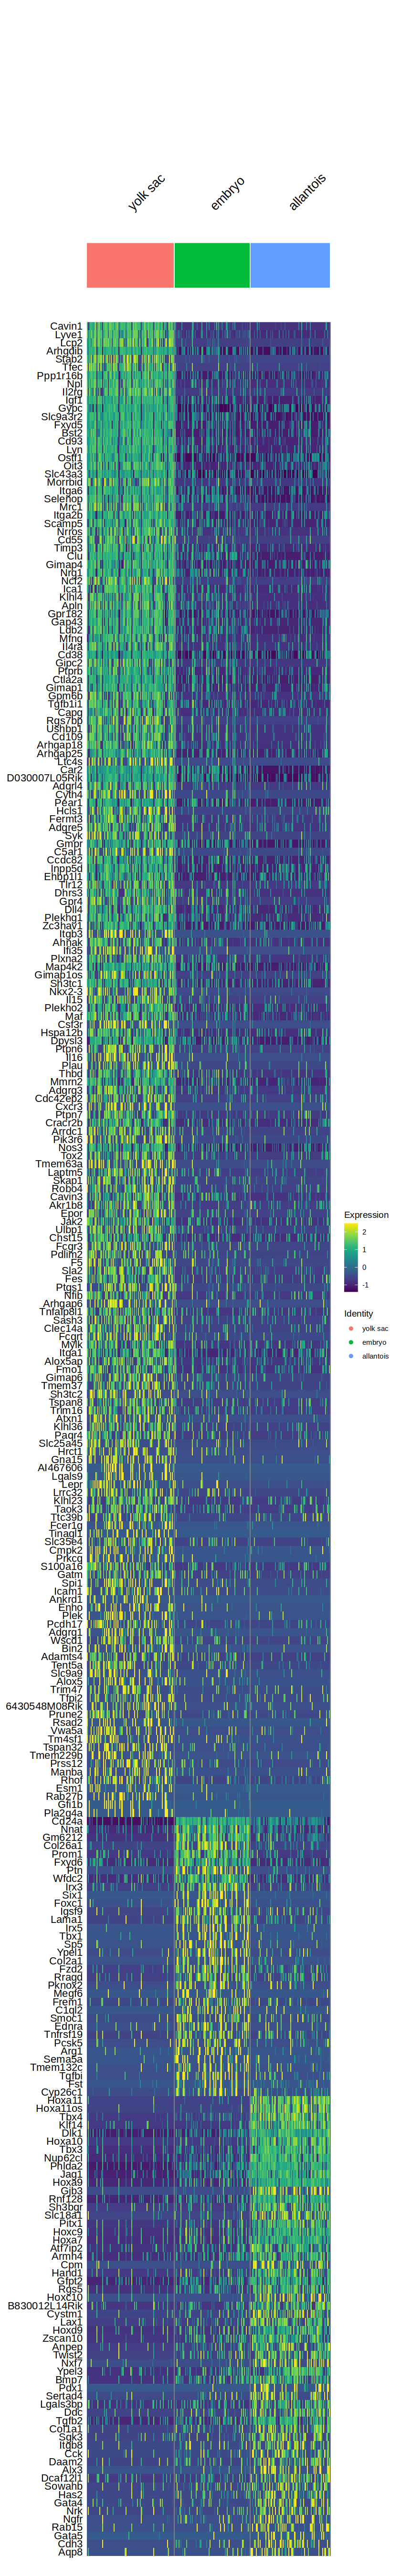

In [11]:
options(repr.plot.height=45)
DoHeatmap(seurat, features = top$gene) + 
    viridis::scale_fill_viridis() + 
    theme(axis.text.y=element_text(color='black', size=13))
#    theme(axis.text.y=element_blank())

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


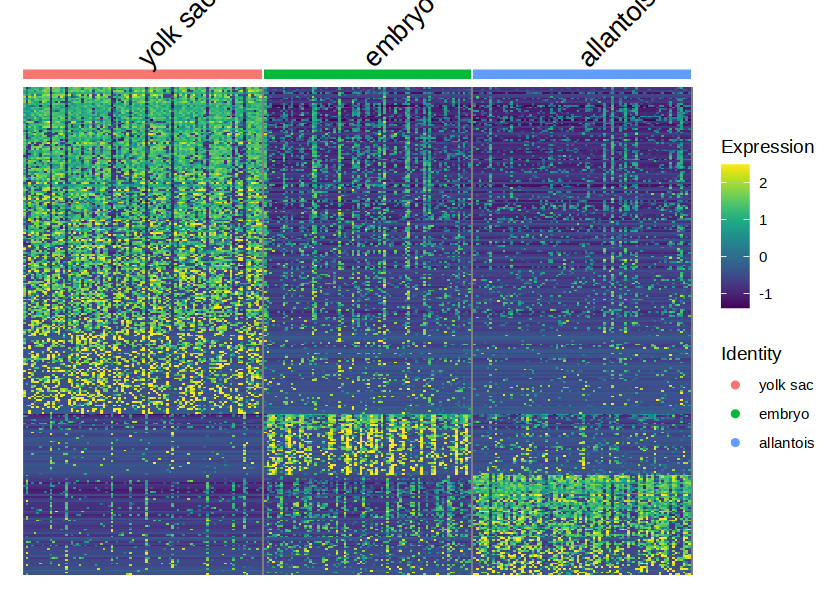

In [148]:
options(repr.plot.height=5)
DoHeatmap(seurat, features = top$gene) + 
    viridis::scale_fill_viridis() + 
#    theme(axis.text.y=element_text(color='black', size=13))
    theme(axis.text.y=element_blank())

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


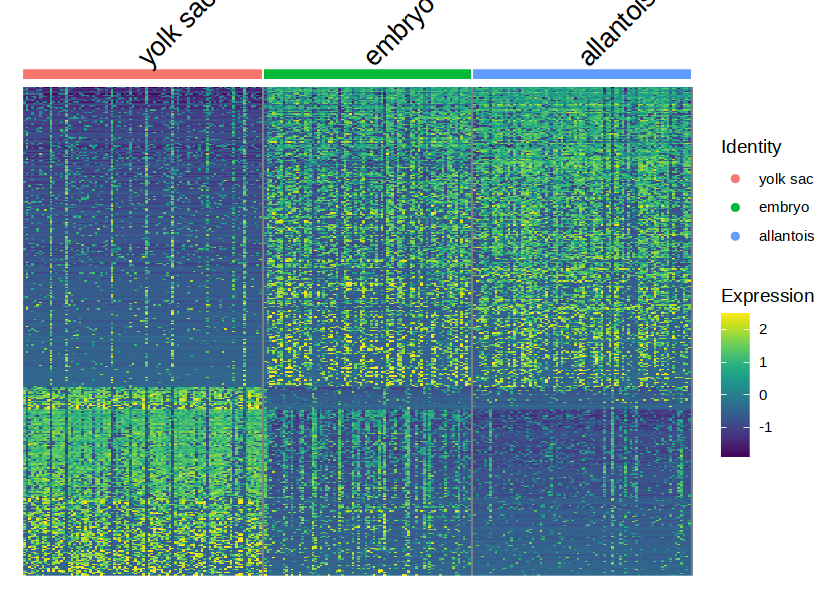

In [153]:
options(repr.plot.height=5)
top = markers %>% 
    group_by(cluster) %>%
        dplyr::filter(avg_log2FC <= -1) %>%
        slice_head(n = 300) %>%
        ungroup()

DoHeatmap(seurat, features = top$gene) + 
    viridis::scale_fill_viridis() + 
#    theme(axis.text.y=element_text(color='black', size=13))
    theme(axis.text.y=element_blank())

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


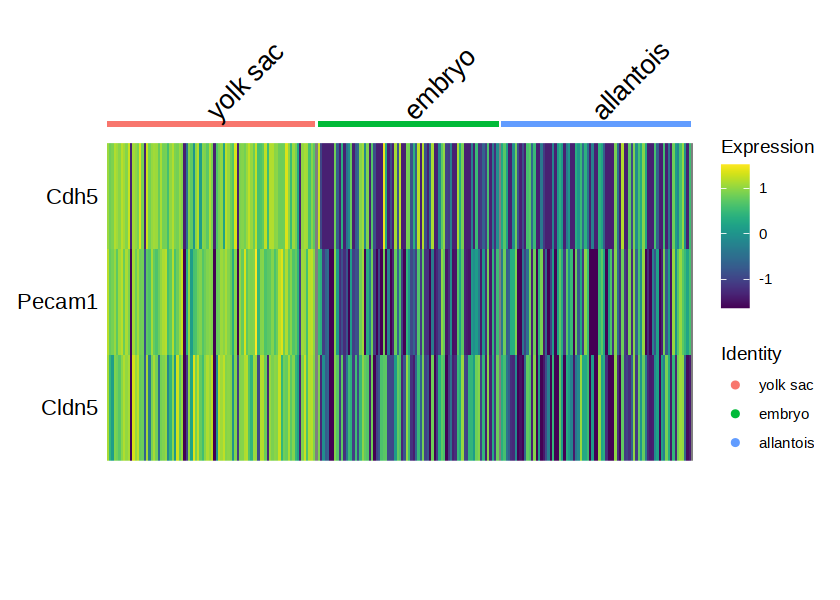

In [139]:
options(repr.plot.height=5)
DoHeatmap(seurat, features = c('Cdh5', 'Pecam1', 'Cldn5')) + 
    viridis::scale_fill_viridis() + 
    theme(axis.text.y=element_text(color='black', size=13))